<a href="https://colab.research.google.com/github/TranNguyenMinhQuan/BaiTapDuLieuSau/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

df = pd.read_csv('processed_dulieuxettuyendaihoc.csv')

df.head()

,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,...,TBM1,TBM2,TBM3,XL1,XL2,XL3,US_TBM1,US_TBM2,US_TBM3,KQXT
0,1,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,...,7.00,7.54,7.01,K,K,K,2.800,3.016,2.804,0.0
1,2,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,...,4.69,5.47,5.07,Y,TB,TB,1.876,2.188,2.028,0.0
2,3,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,...,5.77,5.38,6.04,TB,TB,TB,2.308,2.152,2.416,1.0
3,4,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,...,6.21,5.20,6.88,TB,TB,K,2.484,2.080,2.752,0.0
4,5,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,...,6.50,6.36,6.99,K,TB,K,2.600,2.544,2.796,0.0


In [6]:
df_sorted_dh1 = df.sort_values(by='DH1', ascending=True)

df_sorted_dh2_gt = df.sort_values(by=['GT', 'DH2'], ascending=[True, True])

df_sorted_dh1[['STT', 'GT', 'DH1']].head(10)

,STT,GT,DH1
53,54,M,1.00
43,44,F,1.25
5,6,M,1.50
72,73,M,1.50
83,84,F,1.75
87,88,M,1.75
38,39,M,2.00
12,13,F,2.00
79,80,F,2.00
73,74,F,2.00


In [7]:
def percentile_25(x): return x.quantile(0.25)
def percentile_50(x): return x.quantile(0.50)
def percentile_75(x): return x.quantile(0.75)

agg_funcs = ['count', 'sum', 'mean', 'median', 'min', 'max', 'std', percentile_25, percentile_50, percentile_75]
agg_names = ['Count', 'Sum', 'Mean', 'Median', 'Min', 'Max', 'Std', 'Q1', 'Q2', 'Q3']

pivot_c3 = df.pivot_table(values='DH1', index='KT', aggfunc=agg_funcs)
pivot_c3.columns = agg_names

pivot_c4 = df.pivot_table(values='DH1', index=['KT', 'KV'], aggfunc=agg_funcs)
pivot_c4.columns = agg_names

pivot_c5 = df.pivot_table(values='DH1', index=['KT', 'KV', 'DT'], aggfunc=agg_funcs)
pivot_c5.columns = agg_names

print("--- Thống kê DH1 theo Khối thi (KT) ---")
display(pivot_c3)

--- Thống kê DH1 theo Khối thi (KT) ---


,Count,Sum,Mean,Median,Min,Max,Std,Q1,Q2,Q3
KT,,,,,,,,,,
A,49,163.50,3.336735,3.25,1.00,6.50,1.274296,2.2500,3.25,4.250
A1,6,17.50,2.916667,3.00,2.00,4.25,0.861201,2.1875,3.00,3.250
B,9,29.50,3.277778,3.50,1.75,4.50,0.823905,3.2500,3.50,3.750
C,14,79.25,5.660714,5.25,4.75,7.00,0.812209,5.0625,5.25,6.375
D1,22,84.25,3.829545,3.75,1.25,6.75,1.370146,3.0000,3.75,4.875


    Tần số  Tần suất (%)
GT                      
M       52          52.0
F       48          48.0


/tmp/ipykernel_1185/714119723.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='GT', ax=axes[0], palette='pastel')


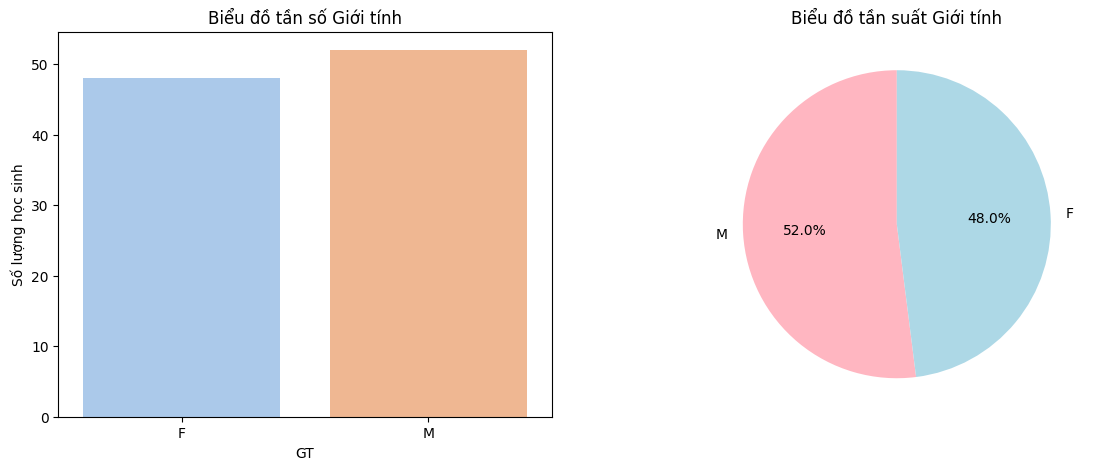

In [8]:
tan_so_gt = df['GT'].value_counts()
tan_suat_gt = df['GT'].value_counts(normalize=True) * 100
thong_ke_gt = pd.DataFrame({'Tần số': tan_so_gt, 'Tần suất (%)': tan_suat_gt})
print(thong_ke_gt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='GT', ax=axes[0], palette='pastel')
axes[0].set_title('Biểu đồ tần số Giới tính')
axes[0].set_ylabel('Số lượng học sinh')

axes[1].pie(tan_suat_gt, labels=tan_suat_gt.index, autopct='%1.1f%%', colors=['lightpink', 'lightblue'], startangle=90)
axes[1].set_title('Biểu đồ tần suất Giới tính')

plt.show()

In [9]:
print("--- Thống kê mô tả US_TBM1, US_TBM2, US_TBM3 ---")
display(df[['US_TBM1', 'US_TBM2', 'US_TBM3']].describe())

print("\n--- Phân phối Dân tộc (DT) ở các học sinh Nam (M) ---")
df_nam = df[df['GT'] == 'M']
display(df_nam['DT'].value_counts().to_frame())

print("\n--- Thống kê Khu vực (KV) đối với học sinh Nam, dân tộc Kinh (0.0), đạt điểm sàn (DH1>=5.0, DH2>=4.0, DH3>=4.0) ---")
df_dk4 = df[(df['GT'] == 'M') & (df['DT'] == 0.0) & (df['DH1'] >= 5.0) & (df['DH2'] >= 4.0) & (df['DH3'] >= 4.0)]
display(df_dk4['KV'].value_counts().to_frame())

print("\n--- Danh sách học sinh thuộc Khu vực 2NT có các điểm DH1, DH2, DH3 >= 5.0 ---")
df_dk5 = df[(df['DH1'] >= 5.0) & (df['DH2'] >= 5.0) & (df['DH3'] >= 5.0) & (df['KV'] == '2NT')]
display(df_dk5[['STT', 'KV', 'DH1', 'DH2', 'DH3']])

--- Thống kê mô tả US_TBM1, US_TBM2, US_TBM3 ---


,US_TBM1,US_TBM2,US_TBM3
count,100.000000,100.000000,100.00000
mean,2.434480,2.559600,2.67176
std,0.391203,0.377656,0.29981
min,1.616000,1.768000,1.91600
25%,2.107000,2.223000,2.47300
50%,2.480000,2.588000,2.70600
75%,2.724000,2.893000,2.87400
max,3.232000,3.416000,3.31600



--- Phân phối Dân tộc (DT) ở các học sinh Nam (M) ---


,count
DT,
0.0,50
1.0,1
6.0,1



--- Thống kê Khu vực (KV) đối với học sinh Nam, dân tộc Kinh (0.0), đạt điểm sàn (DH1>=5.0, DH2>=4.0, DH3>=4.0) ---


,count
KV,
1,2
2,2
2NT,2



--- Danh sách học sinh thuộc Khu vực 2NT có các điểm DH1, DH2, DH3 >= 5.0 ---


,STT,KV,DH1,DH2,DH3
23,24,2NT,6.75,5.25,5.0


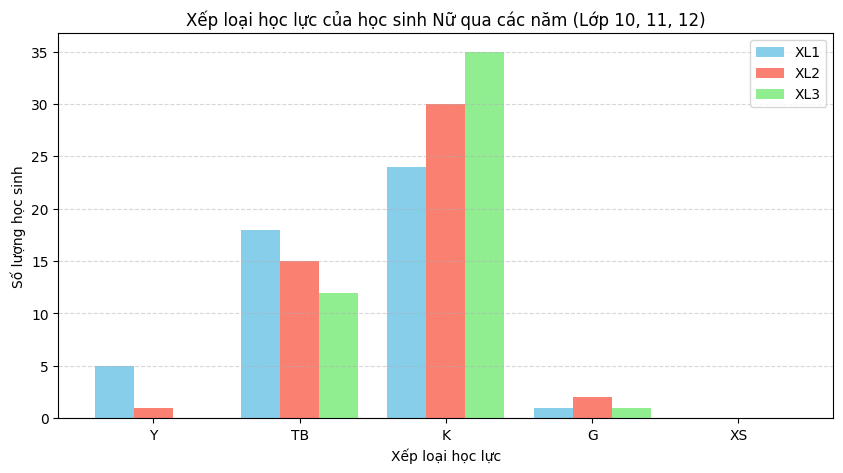

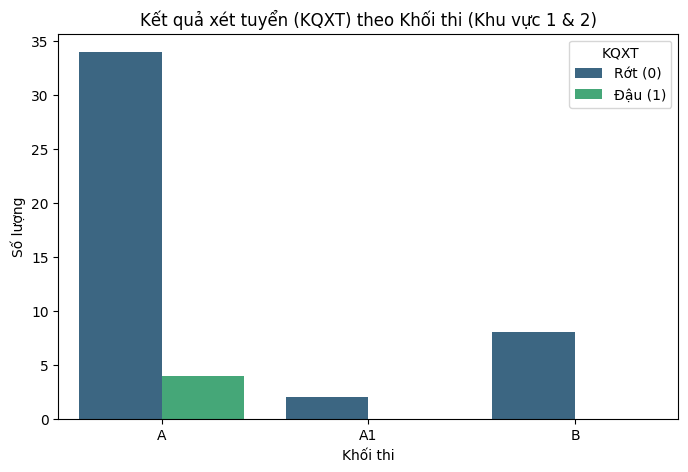

In [10]:
df_nu = df[df['GT'] == 'F']
xl_counts = pd.DataFrame({
    'XL1': df_nu['XL1'].value_counts(),
    'XL2': df_nu['XL2'].value_counts(),
    'XL3': df_nu['XL3'].value_counts()
}).fillna(0).reindex(['Y', 'TB', 'K', 'G', 'XS'])

xl_counts.plot(kind='bar', figsize=(10, 5), width=0.8, color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Xếp loại học lực của học sinh Nữ qua các năm (Lớp 10, 11, 12)')
plt.xlabel('Xếp loại học lực')
plt.ylabel('Số lượng học sinh')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

df_subset2 = df[df['KT'].isin(['A', 'A1', 'B']) & df['KV'].isin(['1', '2'])]
plt.figure(figsize=(8, 5))
sns.countplot(data=df_subset2, x='KT', hue='KQXT', palette='viridis')
plt.title('Kết quả xét tuyển (KQXT) theo Khối thi (Khu vực 1 & 2)')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng')
plt.legend(title='KQXT', labels=['Rớt (0)', 'Đậu (1)'])
plt.show()

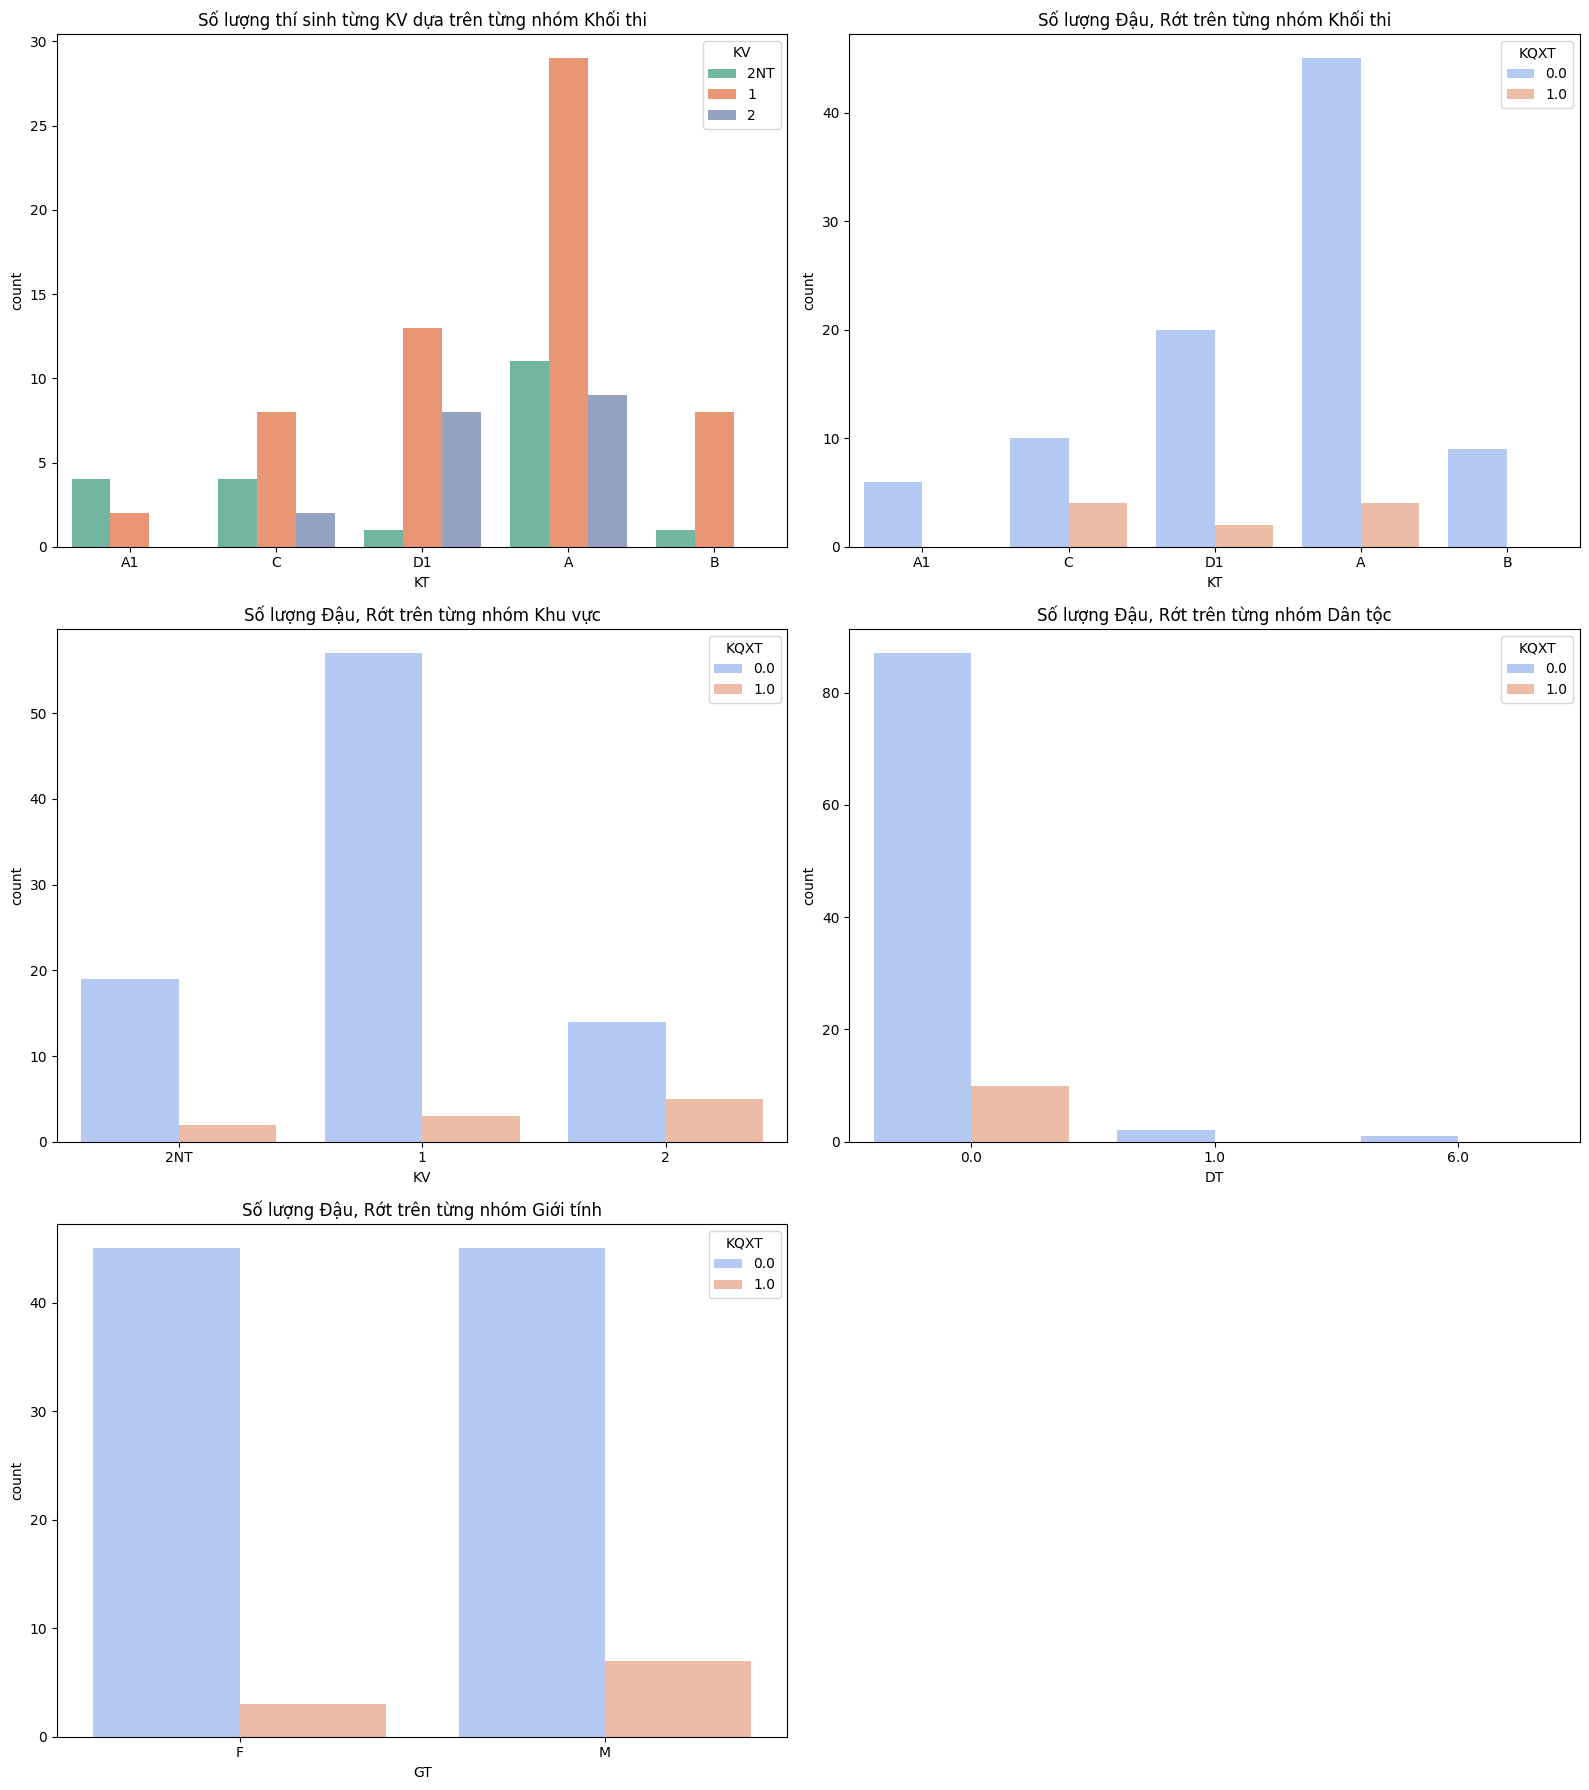

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

sns.countplot(data=df, x='KT', hue='KV', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Số lượng thí sinh từng KV dựa trên từng nhóm Khối thi')

sns.countplot(data=df, x='KT', hue='KQXT', ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Số lượng Đậu, Rớt trên từng nhóm Khối thi')

sns.countplot(data=df, x='KV', hue='KQXT', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Số lượng Đậu, Rớt trên từng nhóm Khu vực')

sns.countplot(data=df, x='DT', hue='KQXT', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Số lượng Đậu, Rớt trên từng nhóm Dân tộc')

sns.countplot(data=df, x='GT', hue='KQXT', ax=axes[2, 0], palette='coolwarm')
axes[2, 0].set_title('Số lượng Đậu, Rớt trên từng nhóm Giới tính')

axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

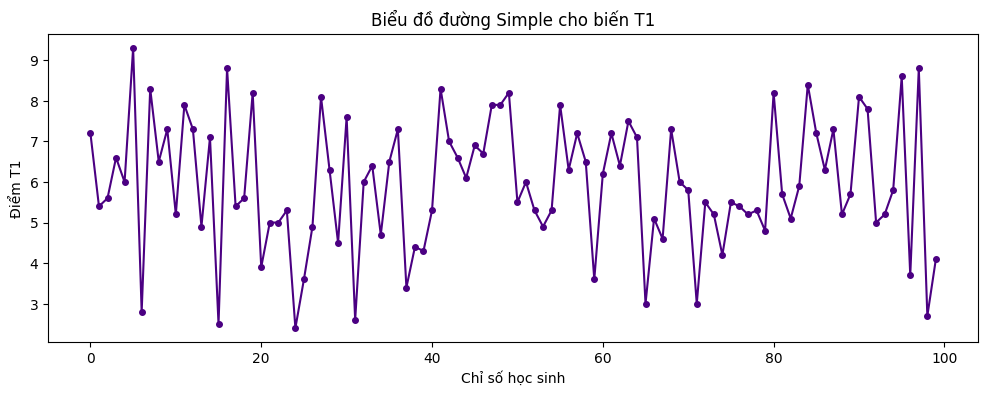

Bảng tần số cho biến phanlopt1:
phanlopt1
k        23
tb       46
k_kha    19
g        12
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(12, 4))
plt.plot(df['T1'], marker='o', linestyle='-', color='indigo', markersize=4)
plt.title('Biểu đồ đường Simple cho biến T1')
plt.xlabel('Chỉ số học sinh')
plt.ylabel('Điểm T1')
plt.show()

def phan_lop_t1(score):
    if score < 5.0: return 'k'
    elif score < 7.0: return 'tb'
    elif score < 8.0: return 'k_kha'
    else: return 'g'

df['phanlopt1'] = df['T1'].apply(phan_lop_t1)

tan_so_t1 = df['phanlopt1'].value_counts().reindex(['k', 'tb', 'k_kha', 'g'])
print("Bảng tần số cho biến phanlopt1:")
print(tan_so_t1)

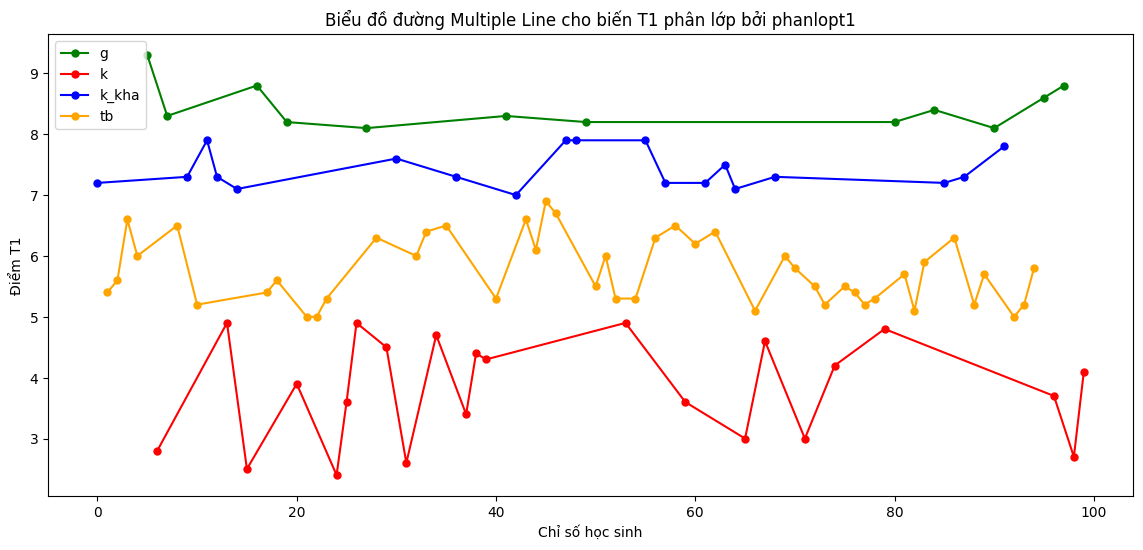

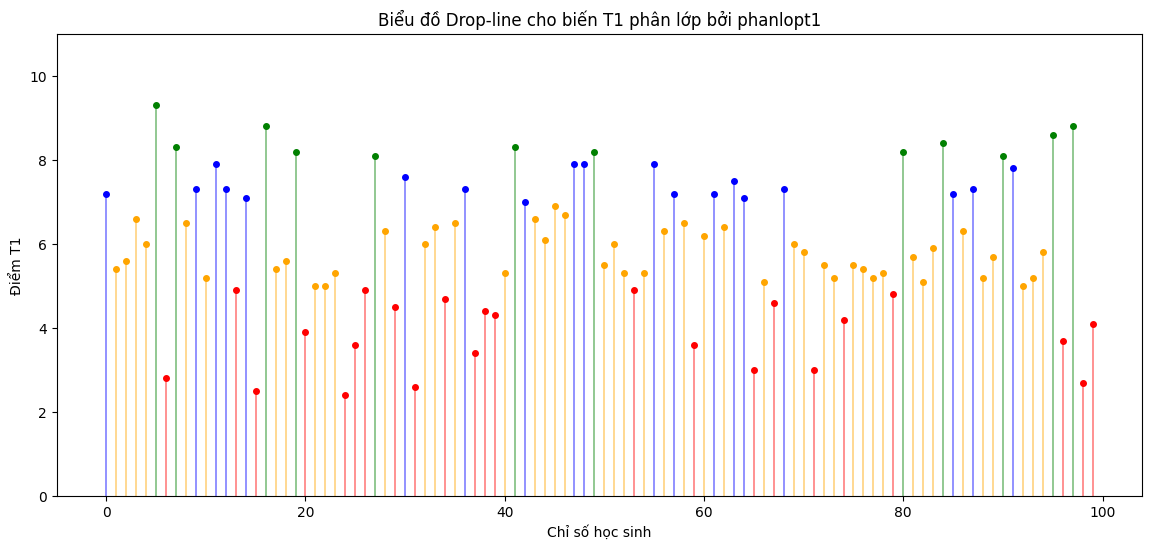

In [13]:
plt.figure(figsize=(14, 6))
colors = {'k': 'red', 'tb': 'orange', 'k_kha': 'blue', 'g': 'green'}
for label, group in df.groupby('phanlopt1'):
    plt.plot(group.index, group['T1'], marker='o', linestyle='-', label=label, color=colors[label], markersize=5)
plt.title('Biểu đồ đường Multiple Line cho biến T1 phân lớp bởi phanlopt1')
plt.xlabel('Chỉ số học sinh')
plt.ylabel('Điểm T1')
plt.legend()
plt.show()

plt.figure(figsize=(14, 6))
for idx, row in df.iterrows():
    plt.vlines(x=idx, ymin=0, ymax=row['T1'], colors=colors[row['phanlopt1']], alpha=0.5, linewidth=1.2)
    plt.plot(idx, row['T1'], marker='o', color=colors[row['phanlopt1']], markersize=4)
plt.title('Biểu đồ Drop-line cho biến T1 phân lớp bởi phanlopt1')
plt.xlabel('Chỉ số học sinh')
plt.ylabel('Điểm T1')
plt.ylim(0, 11)
plt.show()

--- Thống kê mô tả chi tiết của T1 ---
count    100.000000
mean       5.946000
std        1.608338
min        2.400000
25%        5.000000
50%        5.850000
75%        7.200000
max        9.300000
Name: T1, dtype: float64
Độ lệch (Skewness): -0.17824317486762223
Độ nhọn (Kurtosis): -0.48010360836580634


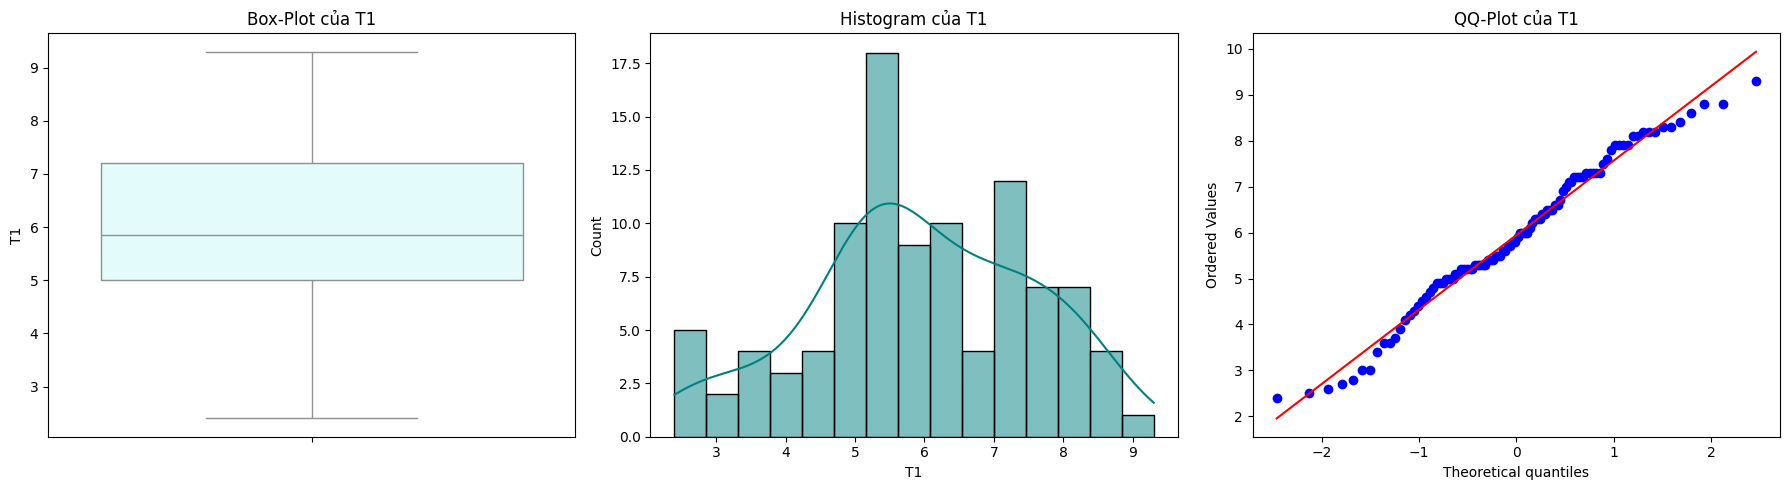

In [14]:
print("--- Thống kê mô tả chi tiết của T1 ---")
print(df['T1'].describe())
print("Độ lệch (Skewness):", df['T1'].skew())
print("Độ nhọn (Kurtosis):", df['T1'].kurt())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, y='T1', ax=axes[0], color='lightcyan')
axes[0].set_title('Box-Plot của T1')

sns.histplot(data=df, x='T1', kde=True, ax=axes[1], color='teal', bins=15)
axes[1].set_title('Histogram của T1')

stats.probplot(df['T1'], dist="norm", plot=axes[2])
axes[2].set_title('QQ-Plot của T1')

plt.tight_layout()
plt.show()

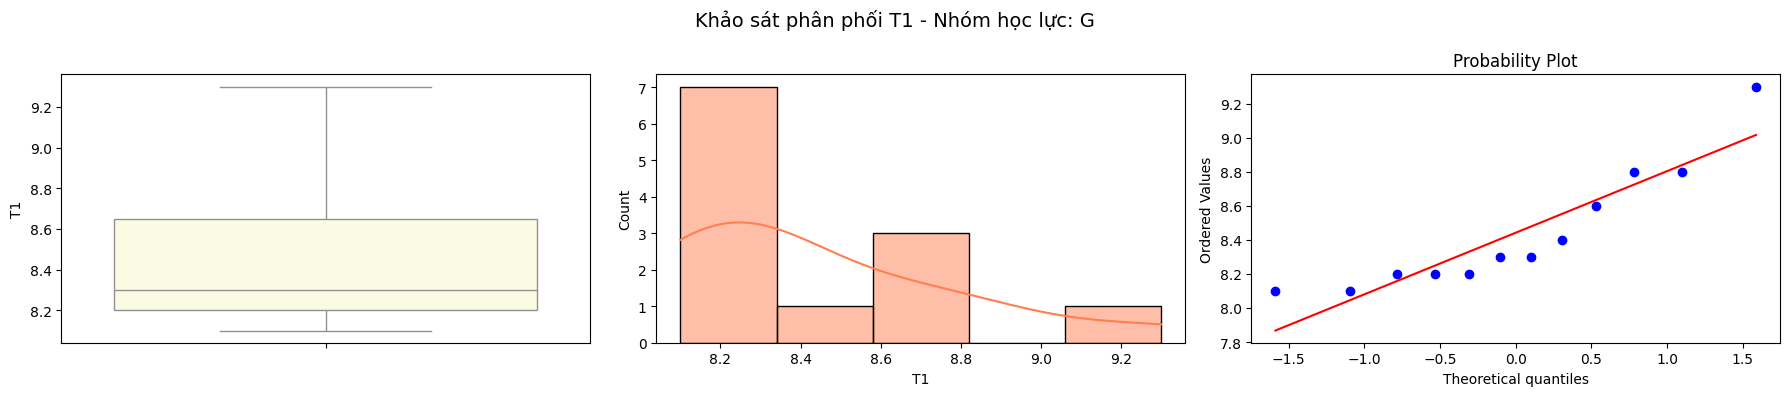

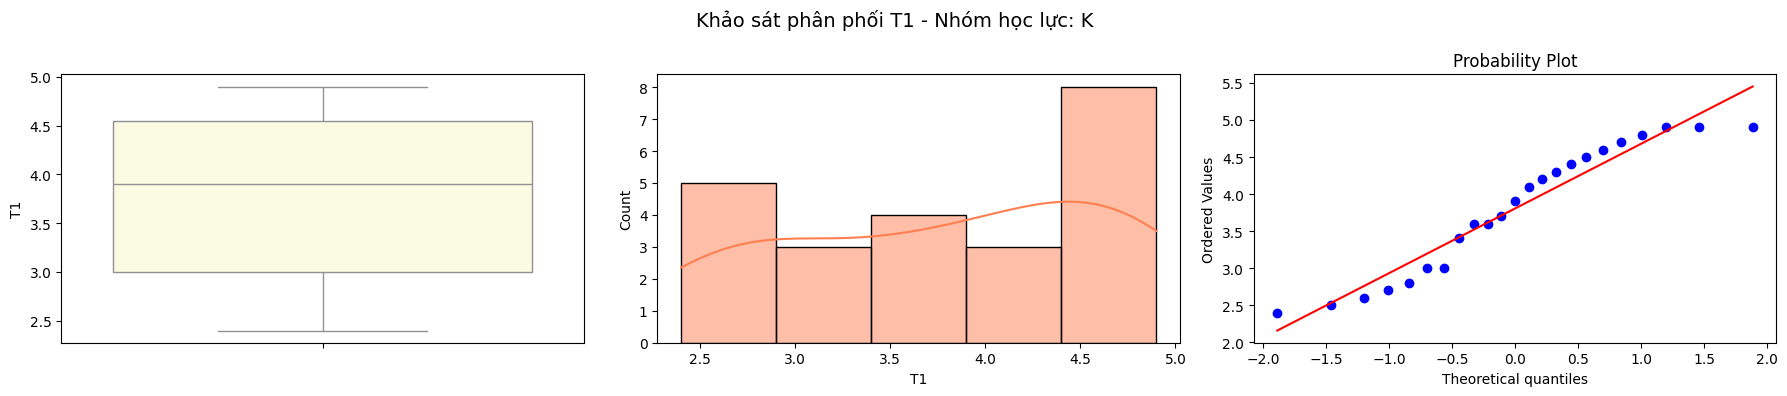

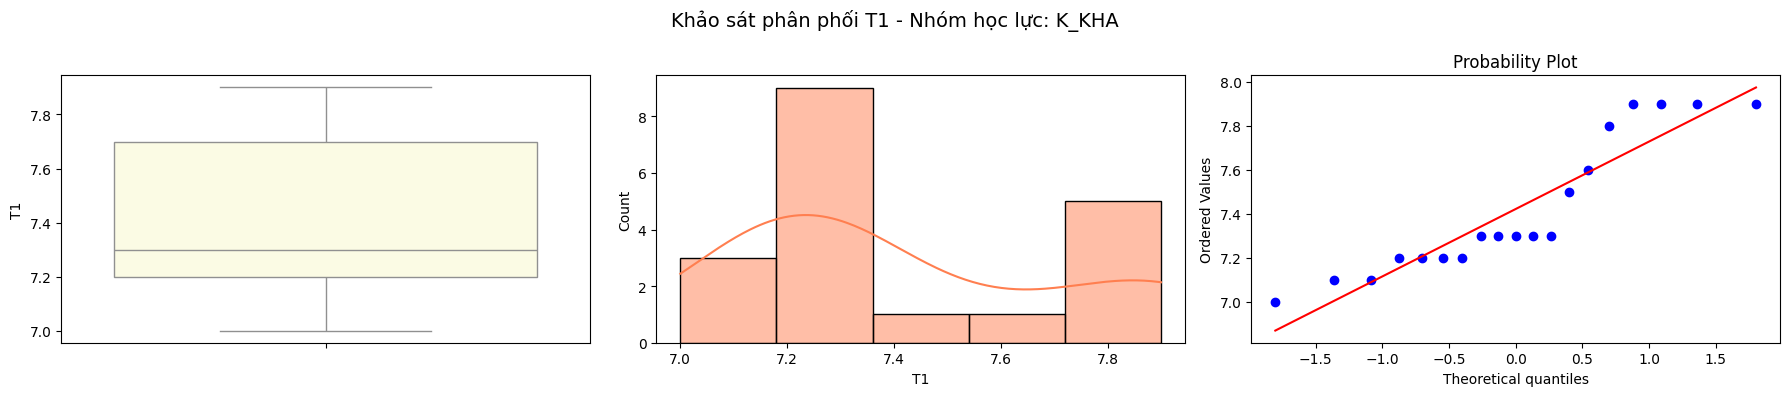

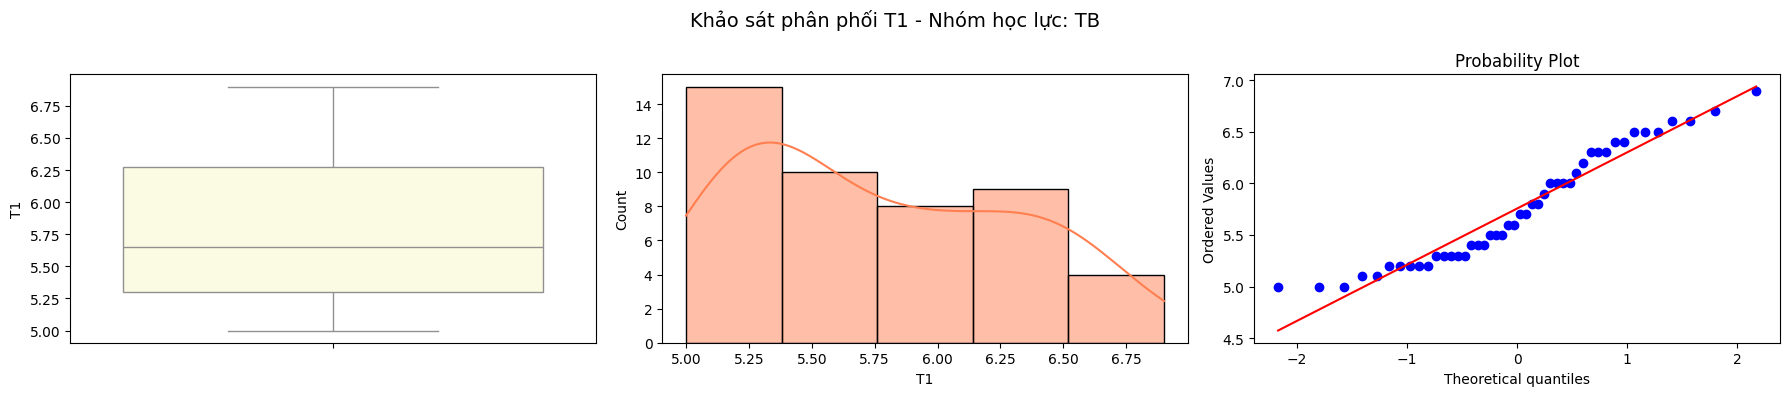

In [15]:
for label, group in df.groupby('phanlopt1'):
    if len(group) > 1:
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        fig.suptitle(f"Khảo sát phân phối T1 - Nhóm học lực: {label.upper()}", fontsize=14)

        sns.boxplot(data=group, y='T1', ax=axes[0], color='lightyellow')
        sns.histplot(data=group, x='T1', kde=True, ax=axes[1], color='coral', bins=5)
        stats.probplot(group['T1'], dist="norm", plot=axes[2])

        plt.tight_layout()
        plt.show()

Hiệp phương sai (Covariance) giữa DH1 và T1: 0.1128
Hệ số tương quan (Correlation) giữa DH1 và T1: 0.0493


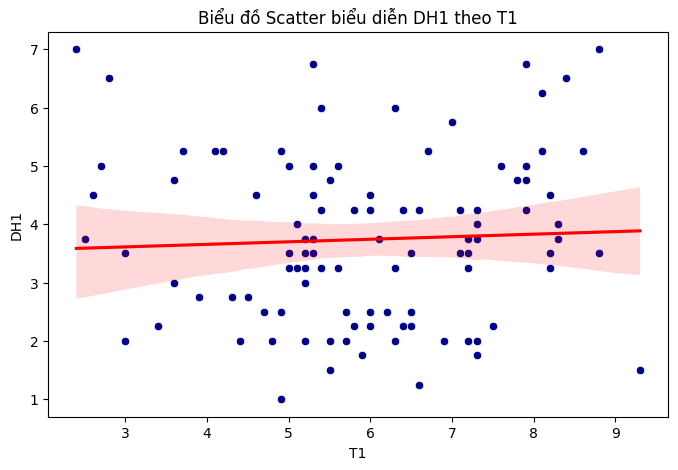

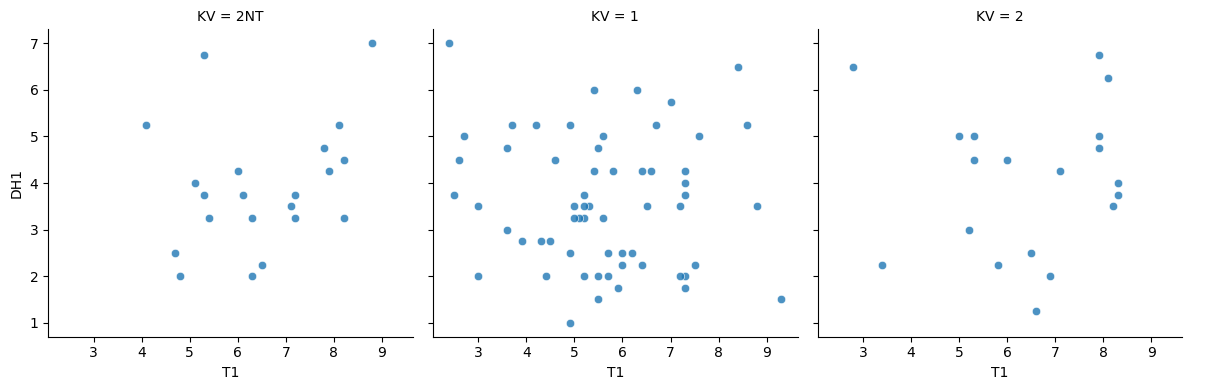


--- Ma trận tương quan giữa DH1, DH2, DH3 ---
          DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000


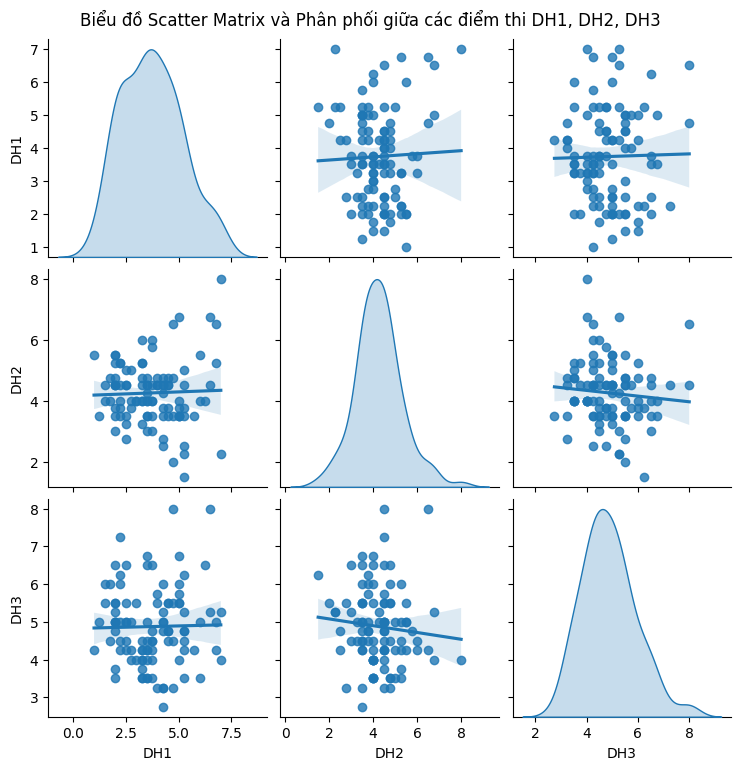

In [16]:
cov_val = df['DH1'].cov(df['T1'])
corr_val = df['DH1'].corr(df['T1'])
print(f"Hiệp phương sai (Covariance) giữa DH1 và T1: {cov_val:.4f}")
print(f"Hệ số tương quan (Correlation) giữa DH1 và T1: {corr_val:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='T1', y='DH1', color='darkblue')
sns.regplot(data=df, x='T1', y='DH1', scatter=False, color='red')
plt.title('Biểu đồ Scatter biểu diễn DH1 theo T1')
plt.show()

g = sns.FacetGrid(df, col="KV", height=4, aspect=1)
g.map(sns.scatterplot, "T1", "DH1", alpha=0.8)
g.add_legend()
plt.show()

matrix_corr = df[['DH1', 'DH2', 'DH3']].corr()
print("\n--- Ma trận tương quan giữa DH1, DH2, DH3 ---")
print(matrix_corr)

sns.pairplot(df[['DH1', 'DH2', 'DH3']], kind='reg', diag_kind='kde')
plt.suptitle('Biểu đồ Scatter Matrix và Phân phối giữa các điểm thi DH1, DH2, DH3', y=1.02)
plt.show()